# Notebook Summary

✔ Dataset Loaded

✔ Exploratory Data Analysis Completed

✔ Data Preprocessing Completed

✔ Feature Engineering Applied

✔ Multiple Machine Learning Models Trained

✔ Model Evaluation Completed

✔ Best Model Selected

✔ Model Saved Successfully

✔ Customer Churn Prediction Pipeline Completed

# Business Conclusion

## Key Findings

- Logistic Regression, Decision Tree, and Random Forest models were evaluated.
- Although the Decision Tree achieved 100% accuracy, feature importance analysis showed it relied entirely on the **Recency** feature.
- This indicates possible target leakage because the churn label appears to be strongly related to Recency.
- Logistic Regression achieved **99.915% accuracy** while using all customer behavior features, making it a more reliable and generalizable model.

## Business Impact

- Predict customers who are likely to churn.
- Support targeted retention campaigns.
- Improve customer satisfaction.
- Reduce revenue loss.
- Enable data-driven customer relationship management.

In [22]:
loaded_model = joblib.load("../models/churn_prediction_model.pkl")

sample_prediction = loaded_model.predict(
    X_test_scaled[:5]
)

print("Actual Labels   :", y_test.iloc[:5].values)
print("Predicted Labels:", sample_prediction)

Actual Labels   : [1 0 0 0 1]
Predicted Labels: [1 0 0 0 1]


In [21]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/churn_prediction_model.pkl")
joblib.dump(scaler, "../models/churn_scaler.pkl")

print("Logistic Regression model saved successfully.")
print("Scaler saved successfully.")

Logistic Regression model saved successfully.
Scaler saved successfully.


,Feature,Coefficient,AbsoluteCoefficient
0,Recency,7.261747,7.261747
7,LastPurchase,-7.257974,7.257974
4,TotalQuantity,-0.310617,0.310617
5,ActiveMonths,-0.150948,0.150948
1,Frequency,0.142917,0.142917
2,Monetary,-0.130999,0.130999
3,AvgOrderValue,0.098314,0.098314
6,FirstPurchase,-0.090159,0.090159


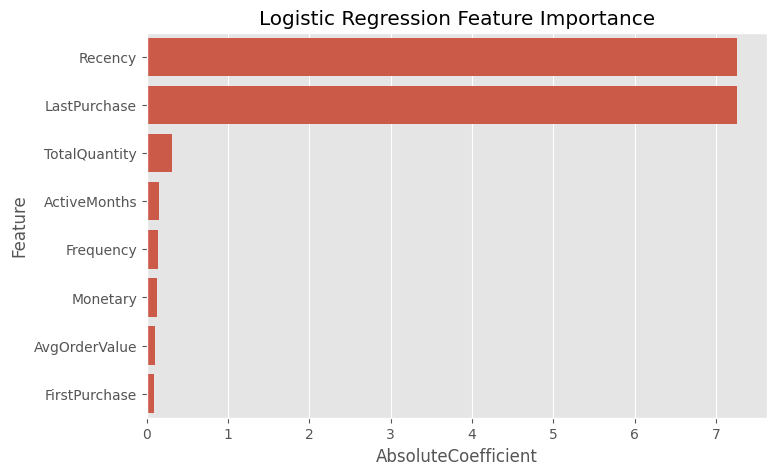

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

importance["AbsoluteCoefficient"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="AbsoluteCoefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Importance")
plt.show()

In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       696
           1       1.00      1.00      1.00       480

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



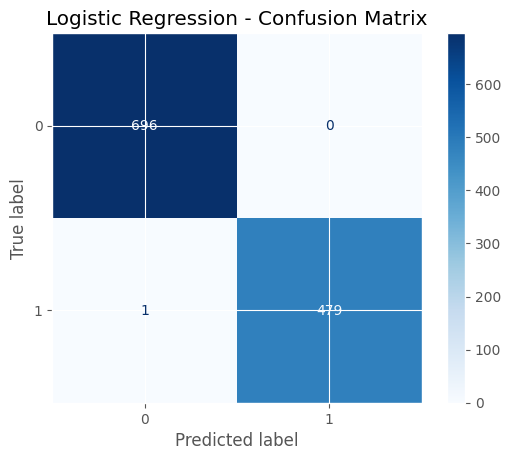

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [18]:
best_model_name = "Logistic Regression"
best_model = lr_model

print("Selected Model for Deployment:", best_model_name)

Selected Model for Deployment: Logistic Regression


In [17]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.00000,1.0,1.000000,1.000000
0,Logistic Regression,0.99915,1.0,0.997917,0.998957
2,Random Forest,0.99915,1.0,0.997917,0.998957


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Random Forest Results
----------------------------------------
Accuracy : 0.9991496598639455
Precision: 1.0
Recall   : 0.9979166666666667
F1 Score : 0.9989572471324296


In [15]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Decision Tree Results
----------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [14]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Logistic Regression Results
----------------------------------------
Accuracy : 0.9991496598639455
Precision: 1.0
Recall   : 0.9979166666666667
F1 Score : 0.9989572471324296


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (4702, 8)
Testing Set  : (1176, 8)


In [11]:
# Convert date columns
churn_df["FirstPurchase"] = pd.to_datetime(churn_df["FirstPurchase"])
churn_df["LastPurchase"] = pd.to_datetime(churn_df["LastPurchase"])

# Convert dates into numerical values
churn_df["FirstPurchase"] = churn_df["FirstPurchase"].map(pd.Timestamp.toordinal)
churn_df["LastPurchase"] = churn_df["LastPurchase"].map(pd.Timestamp.toordinal)

# Features and target
X = churn_df.drop(columns=["CustomerID", "Churn"])
y = churn_df["Churn"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

display(X.head())

Feature Matrix Shape: (5878, 8)
Target Shape: (5878,)


,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,ActiveMonths,FirstPurchase,LastPurchase
0,326,12,77556.46,2281.072353,74285,4,733755,734155
1,2,8,4921.53,22.169054,2967,6,734076,734478
2,75,5,2019.40,39.596078,2714,4,734042,734405
3,19,4,4428.69,25.306800,1624,4,733891,734462
4,310,1,334.40,19.670588,197,1,734170,734170


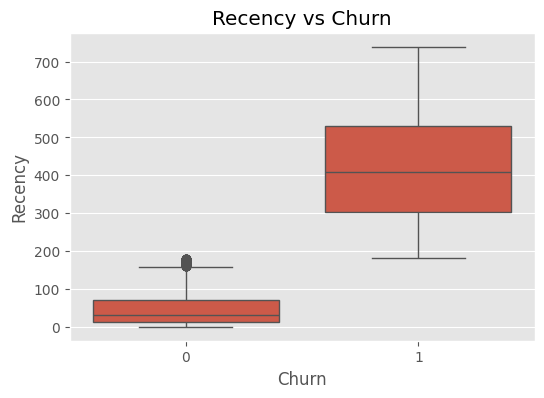

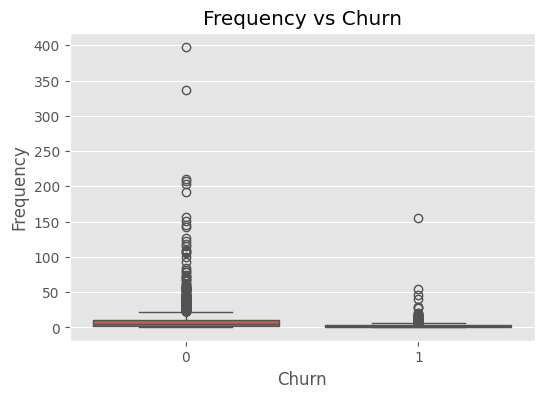

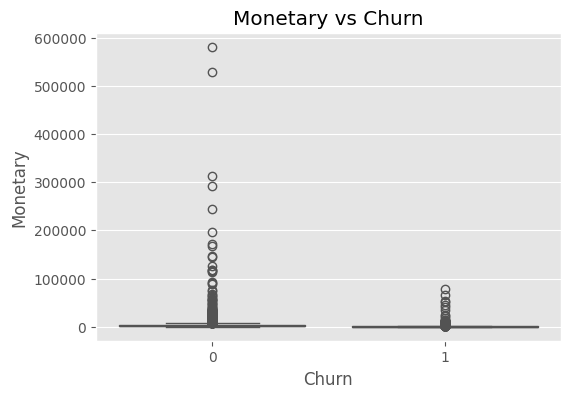

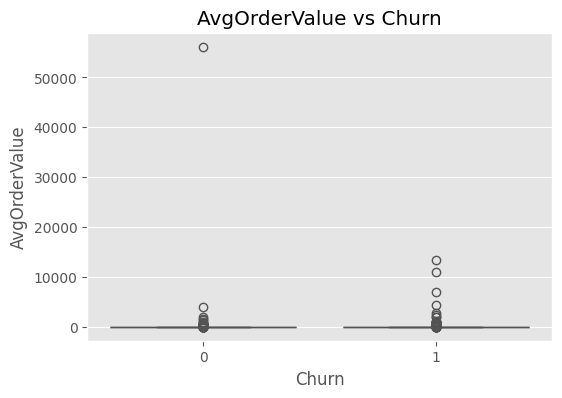

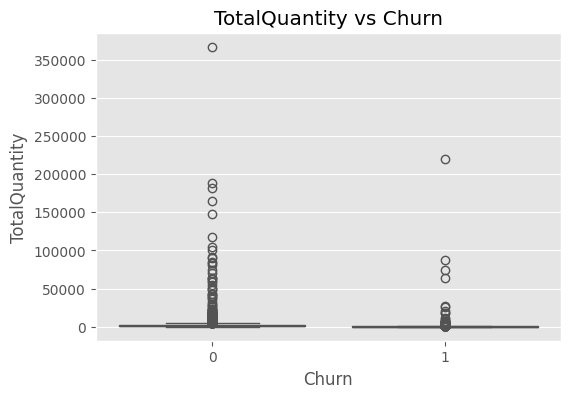

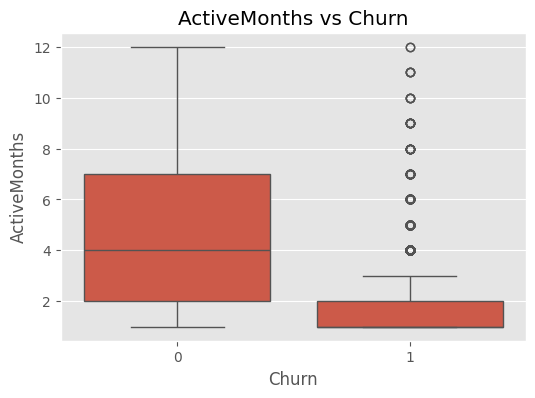

In [10]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "TotalQuantity",
    "ActiveMonths"
]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=churn_df,
        x="Churn",
        y=feature
    )
    plt.title(f"{feature} vs Churn")
    plt.show()

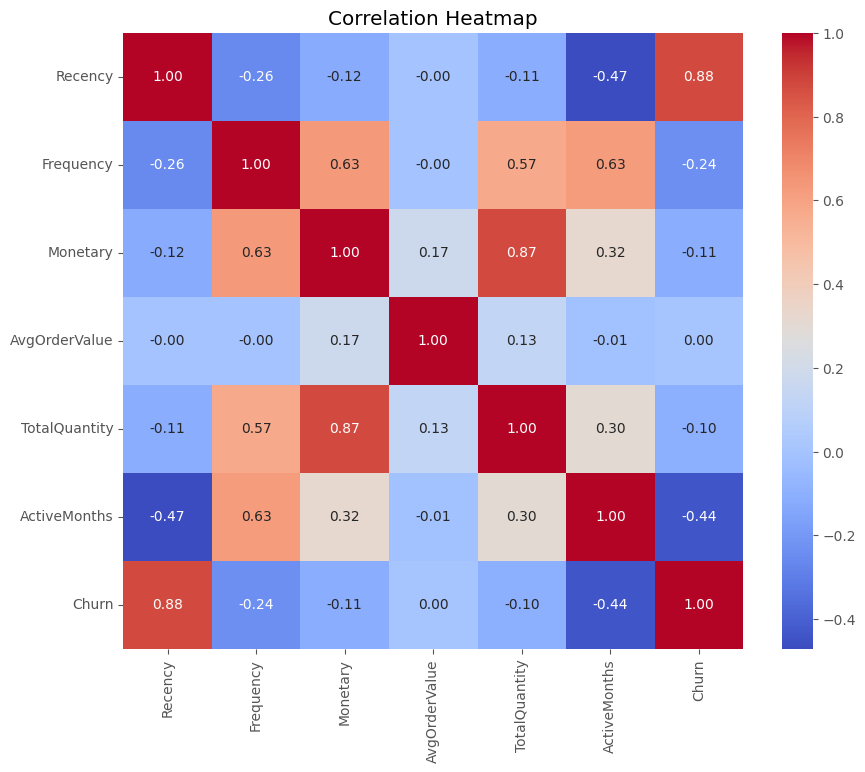

In [9]:
plt.figure(figsize=(10,8))

corr = churn_df.drop(columns=["CustomerID"]).corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
print("Columns in churn_dataset:\n")
for i, col in enumerate(churn_df.columns, start=1):
    print(f"{i}. {col}")

Columns in churn_dataset:

1. CustomerID
2. Recency
3. Frequency
4. Monetary
5. AvgOrderValue
6. TotalQuantity
7. ActiveMonths
8. FirstPurchase
9. LastPurchase
10. Churn


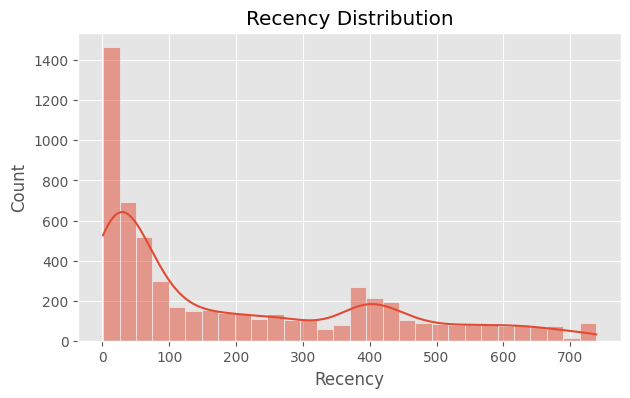

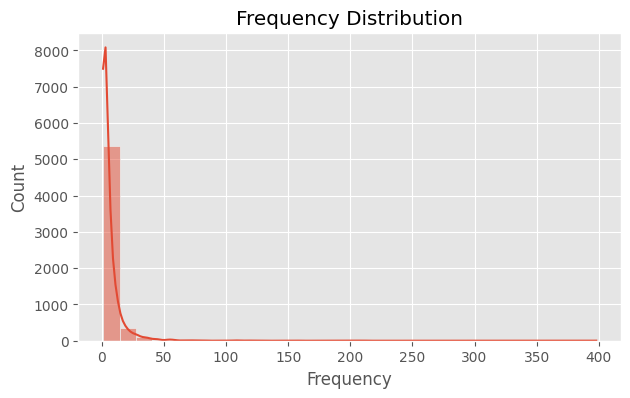

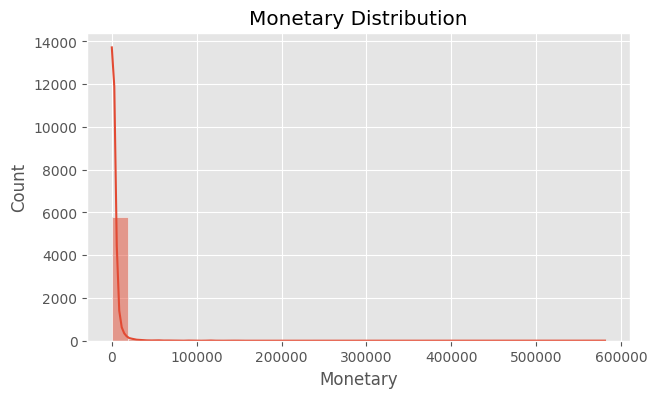

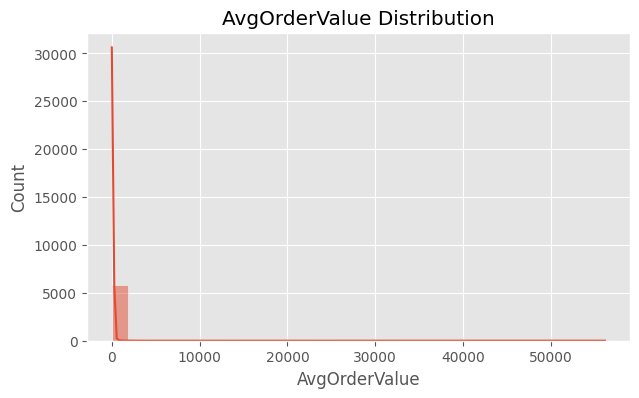

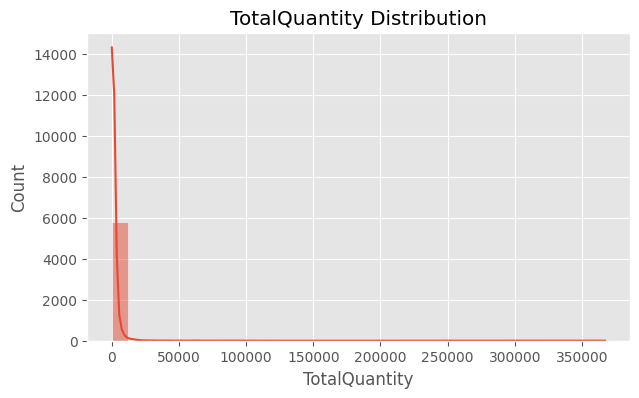

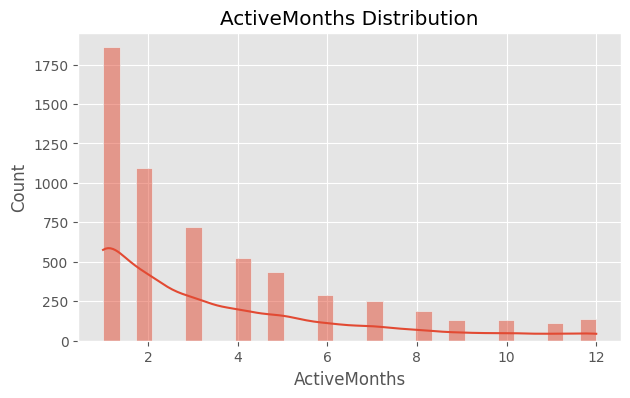

In [7]:
numeric_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "TotalQuantity",
    "ActiveMonths"
]

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(churn_df[col], bins=30, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

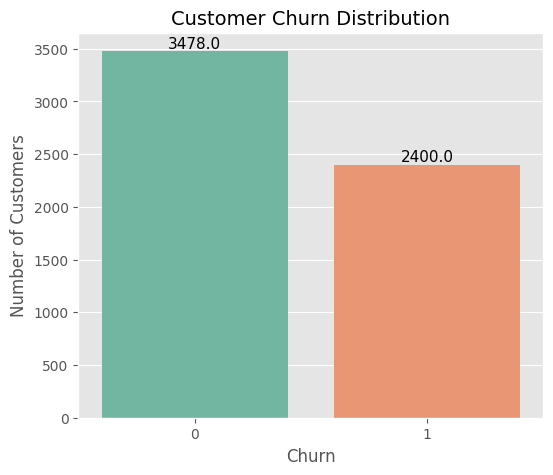

Churn
0    59.169786
1    40.830214
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=churn_df, x="Churn", palette="Set2")

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.show()

print(churn_df["Churn"].value_counts(normalize=True)*100)

In [5]:
display(churn_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
CustomerID,5878.0,15315.313542,1715.572666,12346.000000,13833.25000,15314.500000,16797.7500,18287.00
Recency,5878.0,201.331916,209.338707,1.000000,26.00000,96.000000,380.0000,739.00
Frequency,5878.0,6.289384,13.009406,1.000000,1.00000,3.000000,7.0000,398.00
Monetary,5878.0,2955.904095,14440.852688,2.950000,342.28000,867.740000,2248.3050,580987.04
AvgOrderValue,5878.0,48.301822,780.176769,2.135778,11.56418,17.367639,24.1819,56157.50
TotalQuantity,5878.0,1788.695475,8876.297196,1.000000,187.00000,480.000000,1350.0000,367193.00
ActiveMonths,5878.0,3.556992,2.918215,1.000000,1.00000,2.000000,5.0000,12.00
Churn,5878.0,0.408302,0.491561,0.000000,0.00000,0.000000,1.0000,1.00


In [4]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

display(churn_df.info())

print("\nMissing Values")
display(churn_df.isnull().sum())

print("\nDuplicate Rows:", churn_df.duplicated().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     5878 non-null   float64
 1   Recency        5878 non-null   int64  
 2   Frequency      5878 non-null   int64  
 3   Monetary       5878 non-null   float64
 4   AvgOrderValue  5878 non-null   float64
 5   TotalQuantity  5878 non-null   int64  
 6   ActiveMonths   5878 non-null   int64  
 7   FirstPurchase  5878 non-null   object 
 8   LastPurchase   5878 non-null   object 
 9   Churn          5878 non-null   int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 459.3+ KB


None


Missing Values


CustomerID       0
Recency          0
Frequency        0
Monetary         0
AvgOrderValue    0
TotalQuantity    0
ActiveMonths     0
FirstPurchase    0
LastPurchase     0
Churn            0
dtype: int64


Duplicate Rows: 0


In [3]:
churn_df = pd.read_csv("../data/processed/churn_dataset.csv")

print("Dataset Loaded Successfully")
print("\nShape:", churn_df.shape)

churn_df.head()

Dataset Loaded Successfully

Shape: (5878, 10)


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,ActiveMonths,FirstPurchase,LastPurchase,Churn
0,12346.0,326,12,77556.46,2281.072353,74285,4,2009-12-14 08:34:00,2011-01-18 10:01:00,1
1,12347.0,2,8,4921.53,22.169054,2967,6,2010-10-31 14:20:00,2011-12-07 15:52:00,0
2,12348.0,75,5,2019.40,39.596078,2714,4,2010-09-27 14:59:00,2011-09-25 13:13:00,0
3,12349.0,19,4,4428.69,25.306800,1624,4,2010-04-29 13:20:00,2011-11-21 09:51:00,0
4,12350.0,310,1,334.40,19.670588,197,1,2011-02-02 16:01:00,2011-02-02 16:01:00,1


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Customer Churn Prediction

## Objective
Predict whether a customer is likely to churn using machine learning models based on customer purchasing behavior.

### Workflow
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Train-Test Split
6. Feature Scaling
7. Model Training
8. Model Evaluation
9. Model Comparison
10. Save Best Model